## 00. Install packages (if needed)

In [44]:
# install package
# %pip install numpy pandas matplotlib seaborn scikit-learn

## 01. Import libraries

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split


## 02. Data loading and brief EDA

In [46]:
# Load dataset
df = pd.read_csv('pulsar.csv')
df.head()

,profile_mean,profile_std,profile_kurtosis,profile_skewness,dmsnr_mean,dmsnr_std,dmsnr_kurtosis,dmsnr_skewness,target
0,140.562500,55.683782,-0.234571,-0.699648,3.199833,19.110426,7.975532,74.242225,0
1,102.507812,58.882430,0.465318,-0.515088,1.677258,14.860146,10.576487,127.393580,0
2,103.015625,39.341649,0.323328,1.051164,3.121237,21.744669,7.735822,63.171909,0
3,136.750000,57.178449,-0.068415,-0.636238,3.642977,20.959280,6.896499,53.593661,0
4,88.726562,40.672225,0.600866,1.123492,1.178930,11.468720,14.269573,252.567306,0


In [47]:
# Check dataset dimensions and data types
print(f"Shape: {df.shape}")
print(f"\nData types:\n{df.dtypes}")

Shape: (17898, 9)

Data types:
profile_mean        float64
profile_std         float64
profile_kurtosis    float64
profile_skewness    float64
dmsnr_mean          float64
dmsnr_std           float64
dmsnr_kurtosis      float64
dmsnr_skewness      float64
target                int64
dtype: object


In [48]:
# Check for missing values
print(f"Missing values:{df.isnull().sum().sum()}")
print(f"\nMissing values per column:\n{df.isnull().sum()[df.isnull().sum() > 0]}")

Missing values:0

Missing values per column:
Series([], dtype: int64)


In [49]:
df.describe()

,profile_mean,profile_std,profile_kurtosis,profile_skewness,dmsnr_mean,dmsnr_std,dmsnr_kurtosis,dmsnr_skewness,target
count,17898.000000,17898.000000,17898.000000,17898.000000,17898.000000,17898.000000,17898.000000,17898.000000,17898.000000
mean,111.079968,46.549532,0.477857,1.770279,12.614400,26.326515,8.303556,104.857709,0.091574
std,25.652935,6.843189,1.064040,6.167913,29.472897,19.470572,4.506092,106.514540,0.288432
min,5.812500,24.772042,-1.876011,-1.791886,0.213211,7.370432,-3.139270,-1.976976,0.000000
25%,100.929688,42.376018,0.027098,-0.188572,1.923077,14.437332,5.781506,34.960504,0.000000
50%,115.078125,46.947479,0.223240,0.198710,2.801839,18.461316,8.433515,83.064556,0.000000
75%,127.085938,51.023202,0.473325,0.927783,5.464256,28.428104,10.702959,139.309330,0.000000
max,192.617188,98.778911,8.069522,68.101622,223.392141,110.642211,34.539844,1191.000837,1.000000


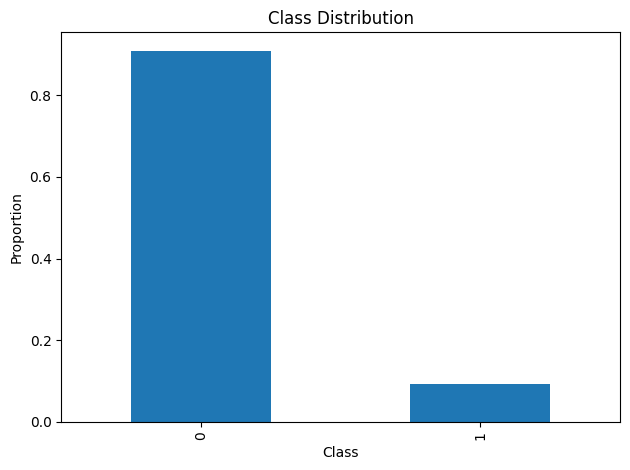

In [50]:
# class bar chart
target_col = df.columns[-1]
class_counts = df[target_col].value_counts(normalize = True)

# plt.figure(figsize=(10, 5))
class_counts.plot(kind='bar')
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Proportion')
plt.tight_layout()
plt.show()

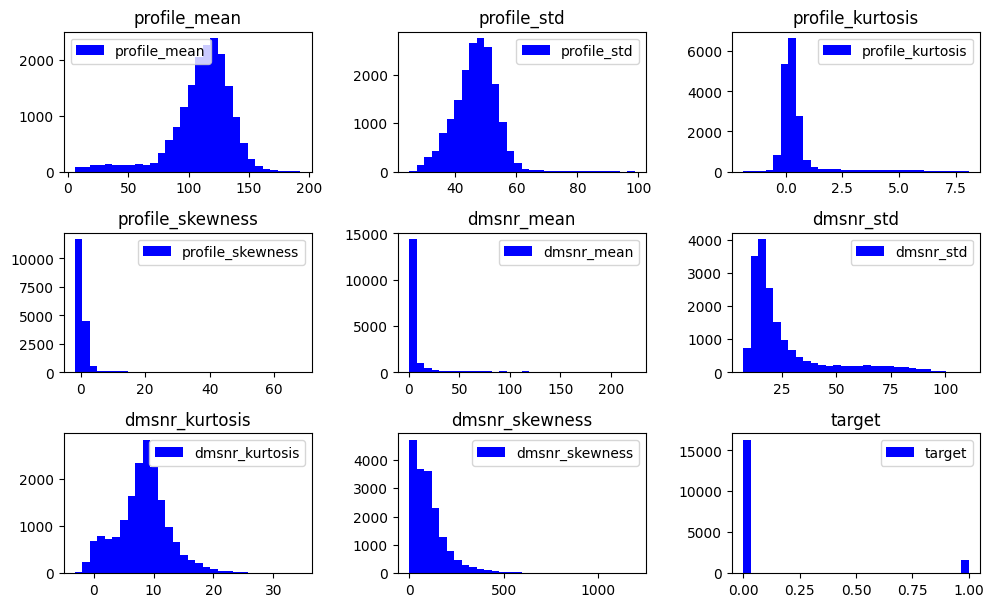

In [51]:
plt.figure(figsize=(10,20))
try:
    for i, col in enumerate(df.columns.to_list()):
        plt.subplot(10, 3, i + 1)
        plt.hist(df[col], label = col, bins = 30, color = 'blue')
        plt.legend()
        plt.title(col)
        plt.tight_layout()
except Exception as e:
    print(col,e)

# reference: https://stackoverflow.com/questions/61030348/how-to-plot-distribution-of-30-features-in-one-plot-and-differentiating-by-label

## 03. Train/test split

In [52]:
y = df["target"]
X = df.drop(columns="target")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, stratify = y, random_state = 42)

## 04. Five-model pipeline